In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
encoded_file = (
    "quantum_encoded_healthcare_data.xlsx"
)

kernel_file = (
    "quantum_kernel_development_results.xlsx"
)

required_files = [
    encoded_file,
    kernel_file
]

missing_files = [
    file for file in required_files
    if not os.path.exists(file)
]

if missing_files:
    raise FileNotFoundError(
        f"Missing required files: {missing_files}\n"
        f"Current folder: {os.getcwd()}"
    )

print("Required files found:")

for file in required_files:
    print("-", os.path.abspath(file))

Required files found:
- C:\Users\HOME\project-healthcare\notebooks\quantum_encoded_healthcare_data.xlsx
- C:\Users\HOME\project-healthcare\notebooks\quantum_kernel_development_results.xlsx


In [3]:
X_train_df = pd.read_excel(
    encoded_file,
    sheet_name="X_Train_Quantum"
)

X_test_df = pd.read_excel(
    encoded_file,
    sheet_name="X_Test_Quantum"
)

y_train_df = pd.read_excel(
    encoded_file,
    sheet_name="Y_Train"
)

y_test_df = pd.read_excel(
    encoded_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    encoded_file,
    sheet_name="Class_Mapping"
)

X_train_full = X_train_df.to_numpy(
    dtype=float
)

X_test_full = X_test_df.to_numpy(
    dtype=float
)

y_train_full = y_train_df[
    "encoded_target"
].to_numpy(dtype=int)

y_test_full = y_test_df[
    "encoded_target"
].to_numpy(dtype=int)

print("Full training features:", X_train_full.shape)
print("Full testing features:", X_test_full.shape)
print("Full training target:", y_train_full.shape)
print("Full testing target:", y_test_full.shape)

Full training features: (400, 4)
Full testing features: (100, 4)
Full training target: (400,)
Full testing target: (100,)


In [4]:
quantum_train_kernel = pd.read_excel(
    kernel_file,
    sheet_name="Train_Kernel",
    index_col=0
).to_numpy(dtype=float)

quantum_test_kernel = pd.read_excel(
    kernel_file,
    sheet_name="Test_Kernel",
    index_col=0
).to_numpy(dtype=float)

subset_indices_df = pd.read_excel(
    kernel_file,
    sheet_name="Subset_Indices"
)

train_indices = (
    subset_indices_df["train_indices"]
    .dropna()
    .astype(int)
    .to_numpy()
)

test_indices = (
    subset_indices_df["test_indices"]
    .dropna()
    .astype(int)
    .to_numpy()
)

print("Training kernel:", quantum_train_kernel.shape)
print("Testing kernel:", quantum_test_kernel.shape)
print("Training subset indices:", train_indices.shape)
print("Testing subset indices:", test_indices.shape)

Training kernel: (96, 96)
Testing kernel: (36, 96)
Training subset indices: (96,)
Testing subset indices: (36,)


In [5]:
y_train_qsvm = y_train_full[
    train_indices
]

y_test_qsvm = y_test_full[
    test_indices
]

X_train_qsvm = X_train_full[
    train_indices
]

X_test_qsvm = X_test_full[
    test_indices
]

print("QSVM training target:", y_train_qsvm.shape)
print("QSVM testing target:", y_test_qsvm.shape)

print("\nTraining class distribution:")
print(
    pd.Series(y_train_qsvm)
    .value_counts()
    .sort_index()
)

print("\nTesting class distribution:")
print(
    pd.Series(y_test_qsvm)
    .value_counts()
    .sort_index()
)

QSVM training target: (96,)
QSVM testing target: (36,)

Training class distribution:
0     8
1     8
2     8
3     8
4     8
5     8
6     8
7     8
8     8
9     8
10    8
11    8
Name: count, dtype: int64

Testing class distribution:
0     3
1     3
2     3
3     3
4     3
5     3
6     3
7     3
8     3
9     3
10    3
11    3
Name: count, dtype: int64


In [6]:
assert quantum_train_kernel.shape == (
    len(y_train_qsvm),
    len(y_train_qsvm)
)

assert quantum_test_kernel.shape == (
    len(y_test_qsvm),
    len(y_train_qsvm)
)

assert np.allclose(
    quantum_train_kernel,
    quantum_train_kernel.T,
    atol=1e-8
)

assert np.allclose(
    np.diag(quantum_train_kernel),
    1.0,
    atol=1e-6
)

assert len(np.unique(y_train_qsvm)) == 12
assert len(np.unique(y_test_qsvm)) == 12

print("Quantum kernel and labels verified.")

Quantum kernel and labels verified.


In [7]:
qsvm_estimator = SVC(
    kernel="precomputed",
    class_weight="balanced",
    decision_function_shape="ovr",
    probability=True,
    random_state=42
)

parameter_grid = {
    "C": [
        0.1,
        1.0,
        10.0,
        100.0
    ]
}

cross_validation = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [8]:
qsvm_grid_search = GridSearchCV(
    estimator=qsvm_estimator,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

qsvm_grid_search.fit(
    quantum_train_kernel,
    y_train_qsvm
)

best_qsvm_model = (
    qsvm_grid_search.best_estimator_
)

print("Best parameters:")
print(qsvm_grid_search.best_params_)

print(
    "Best cross-validation Macro F1:",
    round(
        qsvm_grid_search.best_score_,
        4
    )
)

Best parameters:
{'C': 100.0}
Best cross-validation Macro F1: 0.1448


C:\Users\HOME\anaconda3\envs\healthcare-qml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [9]:
tuning_results = pd.DataFrame(
    qsvm_grid_search.cv_results_
)

tuning_summary = tuning_results[
    [
        "param_C",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

tuning_summary = tuning_summary.sort_values(
    "rank_test_score"
).reset_index(drop=True)

display(tuning_summary.round(4))

,param_C,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,100.0,1.0000,0.0000,0.1448,0.0111,1
1,10.0,0.9544,0.0126,0.1418,0.0116,2
2,1.0,0.8036,0.0117,0.1262,0.0761,3
3,0.1,0.4512,0.0384,0.0950,0.0209,4


In [10]:
qsvm_predictions = best_qsvm_model.predict(
    quantum_test_kernel
)

qsvm_probabilities = (
    best_qsvm_model.predict_proba(
        quantum_test_kernel
    )
)

qsvm_decision_scores = (
    best_qsvm_model.decision_function(
        quantum_test_kernel
    )
)

print("Predictions generated:", len(qsvm_predictions))
print("Probability shape:", qsvm_probabilities.shape)
print("Decision-score shape:", qsvm_decision_scores.shape)

Predictions generated: 36
Probability shape: (36, 12)
Decision-score shape: (36, 12)


In [11]:
model_classes = best_qsvm_model.classes_

qsvm_accuracy = accuracy_score(
    y_test_qsvm,
    qsvm_predictions
)

qsvm_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_qsvm,
        qsvm_predictions
    )
)

qsvm_precision = precision_score(
    y_test_qsvm,
    qsvm_predictions,
    average="macro",
    zero_division=0
)

qsvm_recall = recall_score(
    y_test_qsvm,
    qsvm_predictions,
    average="macro",
    zero_division=0
)

qsvm_macro_f1 = f1_score(
    y_test_qsvm,
    qsvm_predictions,
    average="macro",
    zero_division=0
)

qsvm_weighted_f1 = f1_score(
    y_test_qsvm,
    qsvm_predictions,
    average="weighted",
    zero_division=0
)

qsvm_top_2 = top_k_accuracy_score(
    y_test_qsvm,
    qsvm_decision_scores,
    k=2,
    labels=model_classes
)

qsvm_top_3 = top_k_accuracy_score(
    y_test_qsvm,
    qsvm_decision_scores,
    k=3,
    labels=model_classes
)

qsvm_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Weighted F1-score",
        "Top-2 Accuracy",
        "Top-3 Accuracy"
    ],
    "score": [
        qsvm_accuracy,
        qsvm_balanced_accuracy,
        qsvm_precision,
        qsvm_recall,
        qsvm_macro_f1,
        qsvm_weighted_f1,
        qsvm_top_2,
        qsvm_top_3
    ]
})

qsvm_metrics["score"] = (
    qsvm_metrics["score"].round(4)
)

display(qsvm_metrics)

,metric,score
0,Accuracy,0.1944
1,Balanced Accuracy,0.1944
2,Macro Precision,0.1958
3,Macro Recall,0.1944
4,Macro F1-score,0.1863
5,Weighted F1-score,0.1863
6,Top-2 Accuracy,0.3056
7,Top-3 Accuracy,0.3889


In [12]:
class_mapping_sorted = (
    class_mapping
    .sort_values("encoded_label")
)

class_names = class_mapping_sorted[
    "historical_medication_class"
].tolist()

class_labels = class_mapping_sorted[
    "encoded_label"
].to_numpy(dtype=int)

qsvm_classification_report = pd.DataFrame(
    classification_report(
        y_test_qsvm,
        qsvm_predictions,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(
    qsvm_classification_report.round(4)
)

,precision,recall,f1-score,support
Acid-suppression class A,0.2000,0.3333,0.2500,3.0000
Acid-suppression class B,0.0000,0.0000,0.0000,3.0000
Antidiabetic class A,0.0000,0.0000,0.0000,3.0000
Antidiabetic class B,0.2500,0.3333,0.2857,3.0000
Antihistamine class A,0.0000,0.0000,0.0000,3.0000
Antihistamine class B,0.0000,0.0000,0.0000,3.0000
Antihypertensive class A,0.0000,0.0000,0.0000,3.0000
Antihypertensive class B,0.5000,0.3333,0.4000,3.0000
Bronchodilator class,0.5000,0.3333,0.4000,3.0000
Controller inhaler class,0.0000,0.0000,0.0000,3.0000


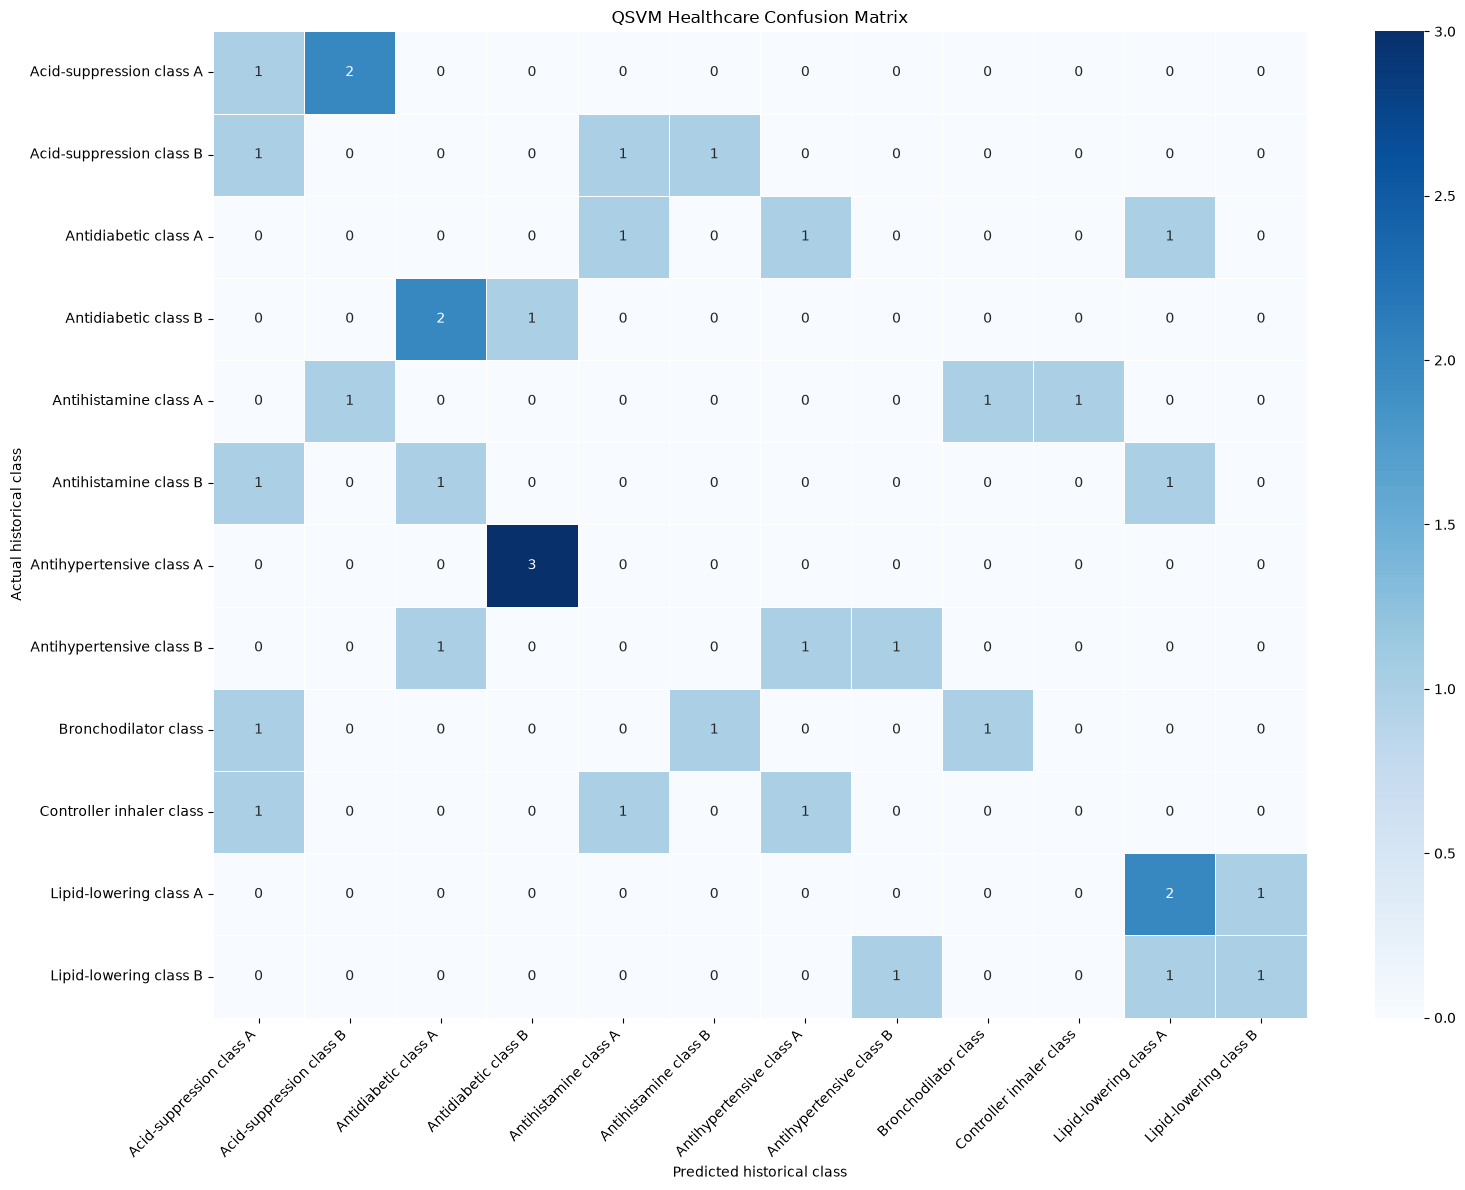

In [13]:
qsvm_confusion = confusion_matrix(
    y_test_qsvm,
    qsvm_predictions,
    labels=class_labels
)

qsvm_confusion_df = pd.DataFrame(
    qsvm_confusion,
    index=class_names,
    columns=class_names
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    qsvm_confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("QSVM Healthcare Confusion Matrix")
plt.xlabel("Predicted historical class")
plt.ylabel("Actual historical class")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [14]:
classical_svm_model = SVC(
    kernel="rbf",
    C=qsvm_grid_search.best_params_["C"],
    gamma="scale",
    class_weight="balanced",
    decision_function_shape="ovr",
    probability=True,
    random_state=42
)

classical_svm_model.fit(
    X_train_qsvm,
    y_train_qsvm
)

classical_predictions = (
    classical_svm_model.predict(
        X_test_qsvm
    )
)

classical_decision_scores = (
    classical_svm_model.decision_function(
        X_test_qsvm
    )
)

print("Classical SVM baseline trained.")

Classical SVM baseline trained.


C:\Users\HOME\anaconda3\envs\healthcare-qml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [15]:
classical_accuracy = accuracy_score(
    y_test_qsvm,
    classical_predictions
)

classical_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_qsvm,
        classical_predictions
    )
)

classical_macro_f1 = f1_score(
    y_test_qsvm,
    classical_predictions,
    average="macro",
    zero_division=0
)

classical_top_3 = top_k_accuracy_score(
    y_test_qsvm,
    classical_decision_scores,
    k=3,
    labels=classical_svm_model.classes_
)

model_comparison = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1-score",
        "Top-3 Accuracy"
    ],
    "QSVM": [
        qsvm_accuracy,
        qsvm_balanced_accuracy,
        qsvm_macro_f1,
        qsvm_top_3
    ],
    "Classical RBF SVM": [
        classical_accuracy,
        classical_balanced_accuracy,
        classical_macro_f1,
        classical_top_3
    ]
})

model_comparison[
    ["QSVM", "Classical RBF SVM"]
] = model_comparison[
    ["QSVM", "Classical RBF SVM"]
].round(4)

display(model_comparison)

,metric,QSVM,Classical RBF SVM
0,Accuracy,0.1944,0.3333
1,Balanced Accuracy,0.1944,0.3333
2,Macro F1-score,0.1863,0.3266
3,Top-3 Accuracy,0.3889,0.6667


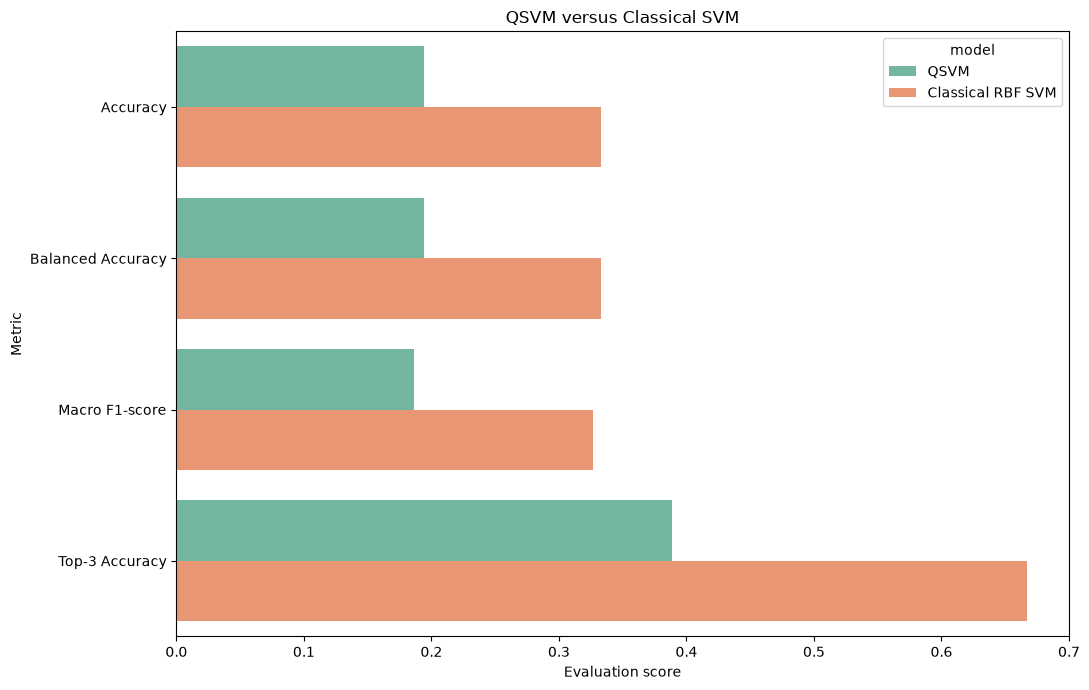

In [16]:
comparison_plot = model_comparison.melt(
    id_vars="metric",
    var_name="model",
    value_name="score"
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=comparison_plot,
    x="score",
    y="metric",
    hue="model",
    palette="Set2"
)

plt.title("QSVM versus Classical SVM")
plt.xlabel("Evaluation score")
plt.ylabel("Metric")

plt.tight_layout()
plt.show()

In [17]:
label_lookup = class_mapping.set_index(
    "encoded_label"
)[
    "historical_medication_class"
].to_dict()

prediction_results = pd.DataFrame({
    "original_test_index":
        test_indices,
    "actual_encoded_class":
        y_test_qsvm,
    "predicted_encoded_class":
        qsvm_predictions,
    "prediction_correct":
        y_test_qsvm == qsvm_predictions,
    "prediction_confidence":
        qsvm_probabilities.max(axis=1)
})

prediction_results[
    "actual_historical_class"
] = prediction_results[
    "actual_encoded_class"
].map(label_lookup)

prediction_results[
    "predicted_historical_class"
] = prediction_results[
    "predicted_encoded_class"
].map(label_lookup)

prediction_results[
    "educational_notice"
] = (
    "Synthetic historical class prediction; "
    "not a prescription"
)

display(prediction_results.head(10))

,original_test_index,actual_encoded_class,predicted_encoded_class,prediction_correct,prediction_confidence,actual_historical_class,predicted_historical_class,educational_notice
0,47,11,11,True,0.144432,Lipid-lowering class B,Lipid-lowering class B,Synthetic historical class prediction; not a p...
1,3,10,10,True,0.131838,Lipid-lowering class A,Lipid-lowering class A,Synthetic historical class prediction; not a p...
2,23,11,10,False,0.118424,Lipid-lowering class B,Lipid-lowering class A,Synthetic historical class prediction; not a p...
3,73,9,4,False,0.137428,Controller inhaler class,Antihistamine class A,Synthetic historical class prediction; not a p...
4,6,7,2,False,0.107152,Antihypertensive class B,Antidiabetic class A,Synthetic historical class prediction; not a p...
5,45,8,8,True,0.152372,Bronchodilator class,Bronchodilator class,Synthetic historical class prediction; not a p...
6,83,0,1,False,0.155792,Acid-suppression class A,Acid-suppression class B,Synthetic historical class prediction; not a p...
7,50,2,6,False,0.115658,Antidiabetic class A,Antihypertensive class A,Synthetic historical class prediction; not a p...
8,72,8,5,False,0.111896,Bronchodilator class,Antihistamine class B,Synthetic historical class prediction; not a p...
9,22,11,7,False,0.153495,Lipid-lowering class B,Antihypertensive class B,Synthetic historical class prediction; not a p...


In [18]:
top_3_positions = np.argsort(
    qsvm_decision_scores,
    axis=1
)[:, -3:][:, ::-1]

for rank in range(3):

    encoded_classes = model_classes[
        top_3_positions[:, rank]
    ]

    prediction_results[
        f"rank_{rank + 1}_class"
    ] = [
        label_lookup[label]
        for label in encoded_classes
    ]

    prediction_results[
        f"rank_{rank + 1}_decision_score"
    ] = qsvm_decision_scores[
        np.arange(
            len(qsvm_decision_scores)
        ),
        top_3_positions[:, rank]
    ]

display(
    prediction_results[
        [
            "actual_historical_class",
            "rank_1_class",
            "rank_2_class",
            "rank_3_class"
        ]
    ].head(10)
)

,actual_historical_class,rank_1_class,rank_2_class,rank_3_class
0,Lipid-lowering class B,Lipid-lowering class B,Antidiabetic class A,Antihypertensive class A
1,Lipid-lowering class A,Lipid-lowering class A,Lipid-lowering class B,Acid-suppression class A
2,Lipid-lowering class B,Lipid-lowering class A,Antihistamine class A,Controller inhaler class
3,Controller inhaler class,Antihistamine class A,Antihistamine class B,Lipid-lowering class A
4,Antihypertensive class B,Antihistamine class A,Antidiabetic class A,Acid-suppression class B
5,Bronchodilator class,Bronchodilator class,Acid-suppression class A,Controller inhaler class
6,Acid-suppression class A,Acid-suppression class B,Controller inhaler class,Acid-suppression class A
7,Antidiabetic class A,Antihypertensive class A,Antihistamine class A,Bronchodilator class
8,Bronchodilator class,Antihistamine class B,Bronchodilator class,Lipid-lowering class B
9,Lipid-lowering class B,Antihypertensive class B,Antihypertensive class A,Antidiabetic class A


In [19]:
output_file = "qsvm_healthcare_model_results.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    qsvm_metrics.to_excel(
        writer,
        sheet_name="QSVM_Metrics",
        index=False
    )

    tuning_summary.to_excel(
        writer,
        sheet_name="Hyperparameter_Tuning",
        index=False
    )

    qsvm_classification_report.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    qsvm_confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix"
    )

    model_comparison.to_excel(
        writer,
        sheet_name="Model_Comparison",
        index=False
    )

    prediction_results.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )

    class_mapping.to_excel(
        writer,
        sheet_name="Class_Mapping",
        index=False
    )

print("Results saved:")
print(os.path.abspath(output_file))

Results saved:
C:\Users\HOME\project-healthcare\notebooks\qsvm_healthcare_model_results.xlsx


In [20]:
qsvm_model_package = {
    "model":
        best_qsvm_model,
    "class_mapping":
        class_mapping,
    "train_indices":
        train_indices,
    "test_indices":
        test_indices,
    "training_kernel_shape":
        quantum_train_kernel.shape,
    "testing_kernel_shape":
        quantum_test_kernel.shape,
    "best_parameters":
        qsvm_grid_search.best_params_,
    "model_type":
        "SVC with precomputed IQP quantum kernel",
    "educational_notice":
        "Synthetic historical class model; not a prescription"
}

model_file = "qsvm_healthcare_model.pkl"

joblib.dump(
    qsvm_model_package,
    model_file
)

print("QSVM package saved:")
print(os.path.abspath(model_file))

QSVM package saved:
C:\Users\HOME\project-healthcare\notebooks\qsvm_healthcare_model.pkl


In [21]:
saved_package = joblib.load(
    model_file
)

assert os.path.exists(output_file)
assert saved_package["training_kernel_shape"] == (
    96,
    96
)
assert saved_package["testing_kernel_shape"] == (
    36,
    96
)
assert len(prediction_results) == 36

print("=" * 60)
print("QSVM HEALTHCARE MODEL COMPLETED")
print("=" * 60)

print("Best parameters:")
print(qsvm_grid_search.best_params_)

print("\nQSVM accuracy:")
print(round(qsvm_accuracy, 4))

print("\nQSVM Macro F1-score:")
print(round(qsvm_macro_f1, 4))

print("\nOutput files:")
print(os.path.abspath(output_file))
print(os.path.abspath(model_file))

QSVM HEALTHCARE MODEL COMPLETED
Best parameters:
{'C': 100.0}

QSVM accuracy:
0.1944

QSVM Macro F1-score:
0.1863

Output files:
C:\Users\HOME\project-healthcare\notebooks\qsvm_healthcare_model_results.xlsx
C:\Users\HOME\project-healthcare\notebooks\qsvm_healthcare_model.pkl
